# Vignette Embedding Analysis
Loads **all 500 personas** x 10 models x 3 conditions (up to 15 000 vignettes),
computes sentence embeddings, selects UMAP `n_neighbors` by maximising
trustworthiness + continuity, projects to 2-D, and computes semantic diversity metrics.

**All heavy computations are cached to disk** in `data/analysis/`.
Delete the relevant file to recompute:
| File | Content |
|---|---|
| `all_vignettes.parquet` | vignette dataframe |
| `embeddings_minilm.npy` | sentence embeddings |
| `neighbor_selection.json` | T & C scores per k |
| `umap_coords_per_condition.npz` | 2-D projections |

In [75]:
import json
import sys
from collections import defaultdict
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.metrics import silhouette_score, pairwise_distances
from sklearn.preprocessing import LabelEncoder

sys.path.insert(0, str(Path("..").resolve()))

ANALYSIS_DIR = Path("../data/analysis")
ANALYSIS_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR = Path("../data/output")

CONDITION_LABELS = {
    "full":           "Full formulation",
    "no_formulation": "No formulation",
    "zero_shot":      "Zero-shot",
}
CONDITION_COLORS = {
    "full":           "#2196F3",
    "no_formulation": "#FF9800",
    "zero_shot":      "#4CAF50",
}
EVAL_MODELS = {
    "gpt-5.4", "gpt-5.4-mini", "gpt-4o-mini",
    "claude-sonnet-4-6", "claude-haiku-4-5",
    "gemini-2.5-flash",
    "deepseek-chat", "deepseek-reasoner",
    "qwen2.5-32b", "qwen3.6-35b",
}
print("Ready")


Ready


## 1. Load all vignettes from output directories (cached)

In [76]:
DF_CACHE = ANALYSIS_DIR / "all_vignettes.parquet"

if DF_CACHE.exists():
    df = pd.read_parquet(DF_CACHE)
    print(f"Loaded {len(df)} cached vignettes")
else:
    groups = defaultdict(list)
    for d in OUTPUT_DIR.iterdir():
        if not d.is_dir() or d.name.startswith("craft_persona"):
            continue
        files = list(d.glob("experiment_*.json"))
        if not files:
            continue
        try:
            with open(files[0], encoding="utf-8") as f:
                cfg = json.load(f).get("config", {})
            model     = next(iter(cfg.get("models", {}).values()), None)
            condition = cfg.get("vignette_mode")
            if model and condition and model in EVAL_MODELS:
                groups[(model, condition)].append((d, len(files)))
        except Exception:
            continue
    best_dirs = {k: max(v, key=lambda x: x[1])[0] for k, v in groups.items()}
    print(f"Found {len(best_dirs)} (model, condition) groups")
    rows = []
    for (model, condition), dirpath in sorted(best_dirs.items()):
        for fp in sorted(dirpath.glob("experiment_*.json")):
            try:
                with open(fp, encoding="utf-8") as f:
                    data = json.load(f)
                text = data.get("vignette", "").strip()
                if not text:
                    continue
                pid = data.get("persona_id") or data.get("source_persona_id")
                rows.append({"persona_id": pid, "model": model,
                             "condition": condition, "vignette": text,
                             "word_count": len(text.split())})
            except Exception:
                continue
    df = pd.DataFrame(rows)
    df.to_parquet(DF_CACHE, index=False)
    print(f"Saved -> {DF_CACHE}")

print(f"Total: {len(df)} vignettes, {df['persona_id'].nunique()} personas")
df.groupby(["condition", "model"]).size().unstack(fill_value=0)


Loaded 14981 cached vignettes
Total: 14981 vignettes, 500 personas


model,claude-haiku-4-5,claude-sonnet-4-6,deepseek-chat,deepseek-reasoner,gemini-2.5-flash,gpt-4o-mini,gpt-5.4,gpt-5.4-mini,qwen2.5-32b,qwen3.6-35b
condition,,,,,,,,,,
full,500,500,500,499,499,500,500,500,500,500
no_formulation,500,500,500,500,500,500,500,500,500,499
zero_shot,500,500,500,500,484,500,500,500,500,500


## 2. Compute embeddings (cached)
Uses  with L2-normalised vectors. ~10-15 min for 15 000 texts.
Delete  to recompute.

In [77]:
EMB_CACHE = ANALYSIS_DIR / "embeddings_mpnet.npy"

if EMB_CACHE.exists():
    embeddings = np.load(EMB_CACHE)
    print(f"Loaded cached embeddings: {embeddings.shape}")
    assert len(embeddings) == len(df), (
        f"Cache mismatch: {len(embeddings)} vs {len(df)} rows. "
        f"Delete {EMB_CACHE} and rerun."
    )
else:
    from sentence_transformers import SentenceTransformer
    print(f"Computing embeddings for {len(df)} vignettes (5-10 min)...")
    enc = SentenceTransformer("all-mpnet-base-v2")
    embeddings = enc.encode(
        df["vignette"].tolist(),
        show_progress_bar=True,
        batch_size=32,
        normalize_embeddings=True,
    )
    np.save(EMB_CACHE, embeddings)
    print(f"Saved -> {EMB_CACHE}  shape={embeddings.shape}")

Loaded cached embeddings: (14981, 768)


## 3. Auto-select UMAP `n_neighbors` (cached)

For each condition we fit UMAP with `n_neighbors` in {2,3,5,8,10,15,20,30} and
compute the **mean of trustworthiness T and continuity C** (Venna & Kaski, 2006):

- **T(k)**: fraction of a point's UMAP k-neighbours that were also neighbours in
  the original space — penalises false proximities.
- **C(k)**: fraction of a point's original k-neighbours retained in UMAP —
  penalises missing proximities.

The k that maximises (T+C)/2 is used for the final projection.
Results saved to `neighbor_selection.json`.

In [78]:
import umap
from sklearn.manifold import trustworthiness

NEIGHBOR_CACHE = ANALYSIS_DIR / "neighbor_selection.json"
CANDIDATES = [2, 3, 5, 8, 10, 15, 20, 30]

if NEIGHBOR_CACHE.exists():
    with open(NEIGHBOR_CACHE) as f:
        neighbor_info = json.load(f)
    print("Loaded cached neighbor selection:")
else:
    neighbor_info = {}
    for cond in CONDITION_LABELS:
        idx   = df[df["condition"] == cond].index.tolist()
        embs  = embeddings[idx]
        cands = [k for k in CANDIDATES if k < len(idx)]
        print(f"\n{CONDITION_LABELS[cond]}  ({len(idx)} vignettes)")
        scores = {}
        for k in cands:
            coords = umap.UMAP(n_components=2, n_neighbors=k,
                               min_dist=0.1, random_state=42).fit_transform(embs)
            t = trustworthiness(embs, coords, n_neighbors=k)
            c = trustworthiness(coords, embs, n_neighbors=k)
            combined = (t + c) / 2
            scores[str(k)] = {"trustworthiness": round(t, 4),
                               "continuity":      round(c, 4),
                               "combined":        round(combined, 4)}
            print(f"  k={k:2d}  T={t:.4f}  C={c:.4f}  mean={combined:.4f}")
        best_n = max(scores, key=lambda k: scores[k]["combined"])
        neighbor_info[cond] = {"best_n": int(best_n), "scores": scores}
        print(f"  -> selected k={best_n}")
    with open(NEIGHBOR_CACHE, "w") as f:
        json.dump(neighbor_info, f, indent=2)
    print(f"Saved -> {NEIGHBOR_CACHE}")

for cond, info in neighbor_info.items():
    print(f"  {CONDITION_LABELS[cond]:<22}  best_n = {info['best_n']}")



Full formulation  (4998 vignettes)


c:\Users\amit\Documents\GitHub\vignette_crafter\venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  k= 2  T=0.9657  C=0.8852  mean=0.9254


c:\Users\amit\Documents\GitHub\vignette_crafter\venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  k= 3  T=0.9688  C=0.9160  mean=0.9424


...

  k=15  T=0.9215  C=0.9159  mean=0.9187


c:\Users\amit\Documents\GitHub\vignette_crafter\venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  k=20  T=0.9148  C=0.9076  mean=0.9112


c:\Users\amit\Documents\GitHub\vignette_crafter\venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  k=30  T=0.9039  C=0.8933  mean=0.8986
  -> selected k=3
Saved -> ..\data\analysis\neighbor_selection.json
  Full formulation        best_n = 3
  No formulation          best_n = 3
  Zero-shot               best_n = 3


### 3a. Neighbor-selection plot (methods figure)

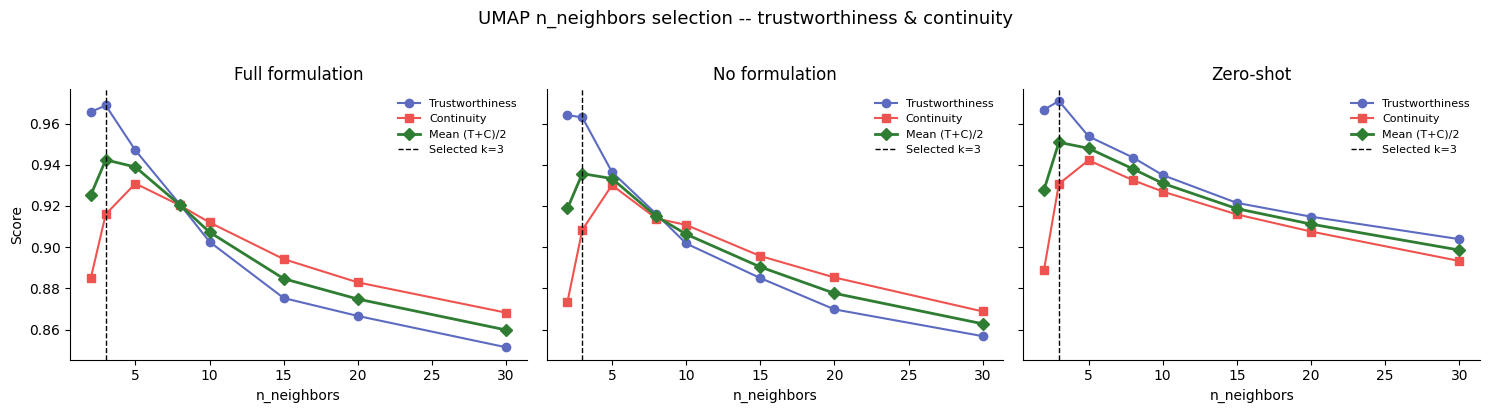

Saved -> ..\data\analysis\umap_neighbor_selection.png


In [79]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, cond in zip(axes, CONDITION_LABELS):
    info   = neighbor_info[cond]
    ks     = sorted(int(k) for k in info["scores"])
    t_vals = [info["scores"][str(k)]["trustworthiness"] for k in ks]
    c_vals = [info["scores"][str(k)]["continuity"]      for k in ks]
    m_vals = [info["scores"][str(k)]["combined"]         for k in ks]
    ax.plot(ks, t_vals, "o-", label="Trustworthiness", color="#5C6BC0")
    ax.plot(ks, c_vals, "s-", label="Continuity",      color="#EF5350")
    ax.plot(ks, m_vals, "D-", label="Mean (T+C)/2",    color="#2E7D32", linewidth=2)
    ax.axvline(info["best_n"], color="black", linestyle="--", linewidth=1,
               label=f"Selected k={info['best_n']}")
    ax.set_title(CONDITION_LABELS[cond], fontsize=12)
    ax.set_xlabel("n_neighbors", fontsize=10)
    if ax is axes[0]:
        ax.set_ylabel("Score", fontsize=10)
    ax.legend(fontsize=8, frameon=False)
    ax.spines[["top", "right"]].set_visible(False)
plt.suptitle("UMAP n_neighbors selection -- trustworthiness & continuity",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(ANALYSIS_DIR / "umap_neighbor_selection.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved -> {ANALYSIS_DIR / 'umap_neighbor_selection.png'}")


## 4. Compute UMAP projections (cached)

In [80]:
UMAP_CACHE = ANALYSIS_DIR / "umap_coords_per_condition.npz"

if UMAP_CACHE.exists():
    cache = np.load(UMAP_CACHE)
    umap_coords = {k: cache[k] for k in cache.files}
    print("Loaded cached UMAP coords:", {k: v.shape for k, v in umap_coords.items()})
else:
    umap_coords = {}
    for cond in CONDITION_LABELS:
        idx    = df[df["condition"] == cond].index.tolist()
        embs   = embeddings[idx]
        best_n = neighbor_info[cond]["best_n"]
        print(f"{CONDITION_LABELS[cond]}: n_neighbors={best_n}, {len(idx)} vignettes...")
        coords = umap.UMAP(n_components=2, n_neighbors=best_n,
                           min_dist=0.1, random_state=42).fit_transform(embs)
        umap_coords[cond] = coords
        print(f"  done {coords.shape}")
    np.savez(UMAP_CACHE, **umap_coords)
    print(f"Saved -> {UMAP_CACHE}")


Full formulation: n_neighbors=3, 4998 vignettes...


c:\Users\amit\Documents\GitHub\vignette_crafter\venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  done (4998, 2)
No formulation: n_neighbors=3, 4999 vignettes...


c:\Users\amit\Documents\GitHub\vignette_crafter\venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  done (4999, 2)
Zero-shot: n_neighbors=3, 4984 vignettes...


c:\Users\amit\Documents\GitHub\vignette_crafter\venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  done (4984, 2)
Saved -> ..\data\analysis\umap_coords_per_condition.npz


## 5. UMAP plots
### 5a. Colored by model

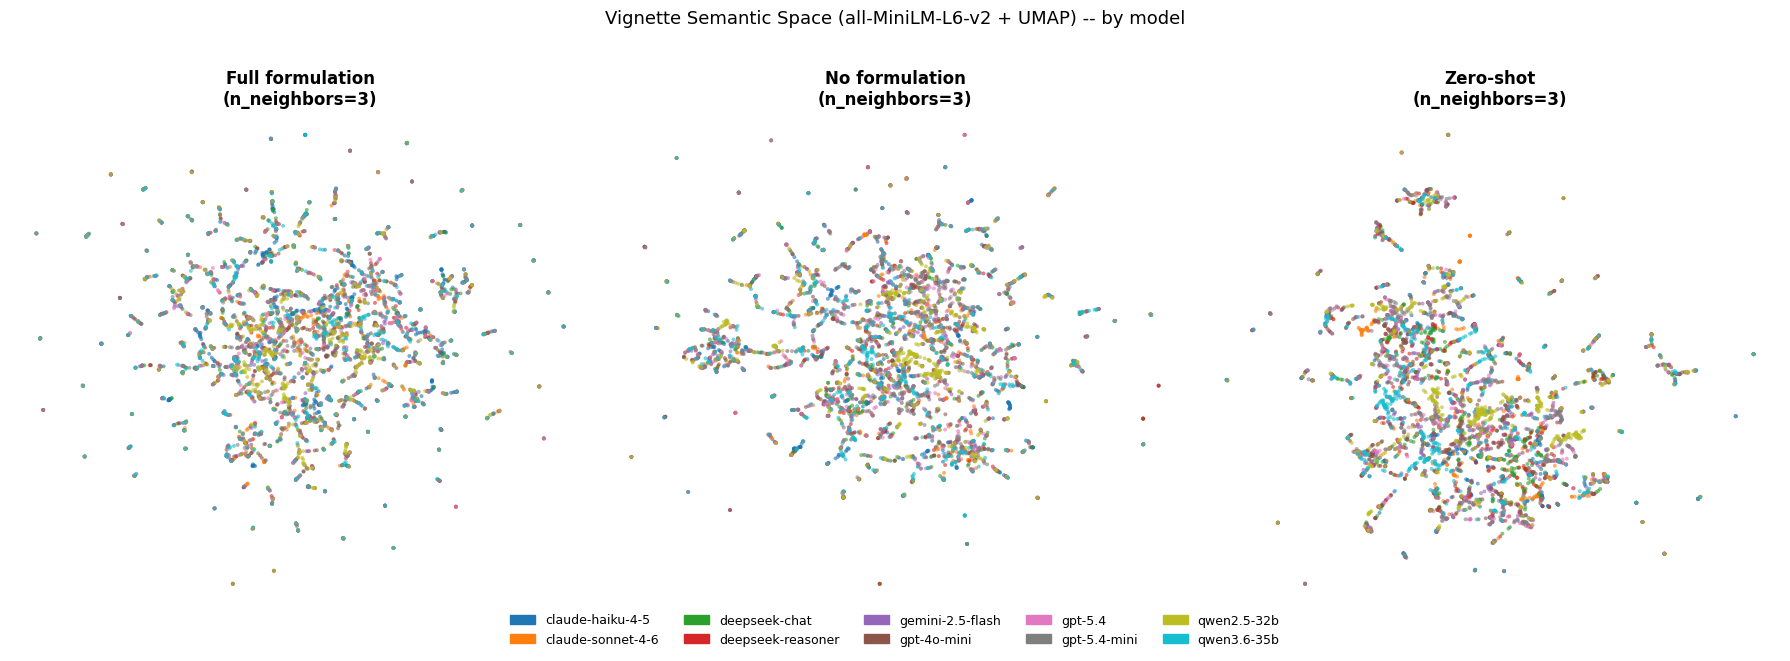

In [96]:
models = sorted(df["model"].unique())
model_color = dict(zip(models, sns.color_palette("tab10", n_colors=len(models))))

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, cond in zip(axes, CONDITION_LABELS):
    idx     = df[df["condition"] == cond].index
    cond_df = df.loc[idx].reset_index(drop=True)
    coords  = umap_coords[cond]
    best_n  = neighbor_info[cond]["best_n"]
    for model in models:
        mask = (cond_df["model"] == model).values
        ax.scatter(coords[mask, 0], coords[mask, 1],
                   c=[model_color[model]], s=8, alpha=0.6, edgecolors="none")
    ax.set_title(f"{CONDITION_LABELS[cond]}\n(n_neighbors={best_n})",
                 fontsize=12, fontweight="bold")
    ax.set_xticks([]); ax.set_yticks([])
    ax.spines[["top", "right", "left", "bottom"]].set_visible(False)
handles = [mpatches.Patch(color=model_color[m], label=m) for m in models]
fig.legend(handles=handles, loc="lower center", ncol=5,
           fontsize=9, bbox_to_anchor=(0.5, -0.06), frameon=False)
plt.suptitle("Vignette Semantic Space (all-MiniLM-L6-v2 + UMAP) -- by model",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(ANALYSIS_DIR / "umap_by_condition_model.png", dpi=150, bbox_inches="tight")
plt.show()


### 5c. Grid: one row per model, one column per condition
Gray points = all other models in that condition's UMAP space.
Colored points = this model's vignettes (color = condition).

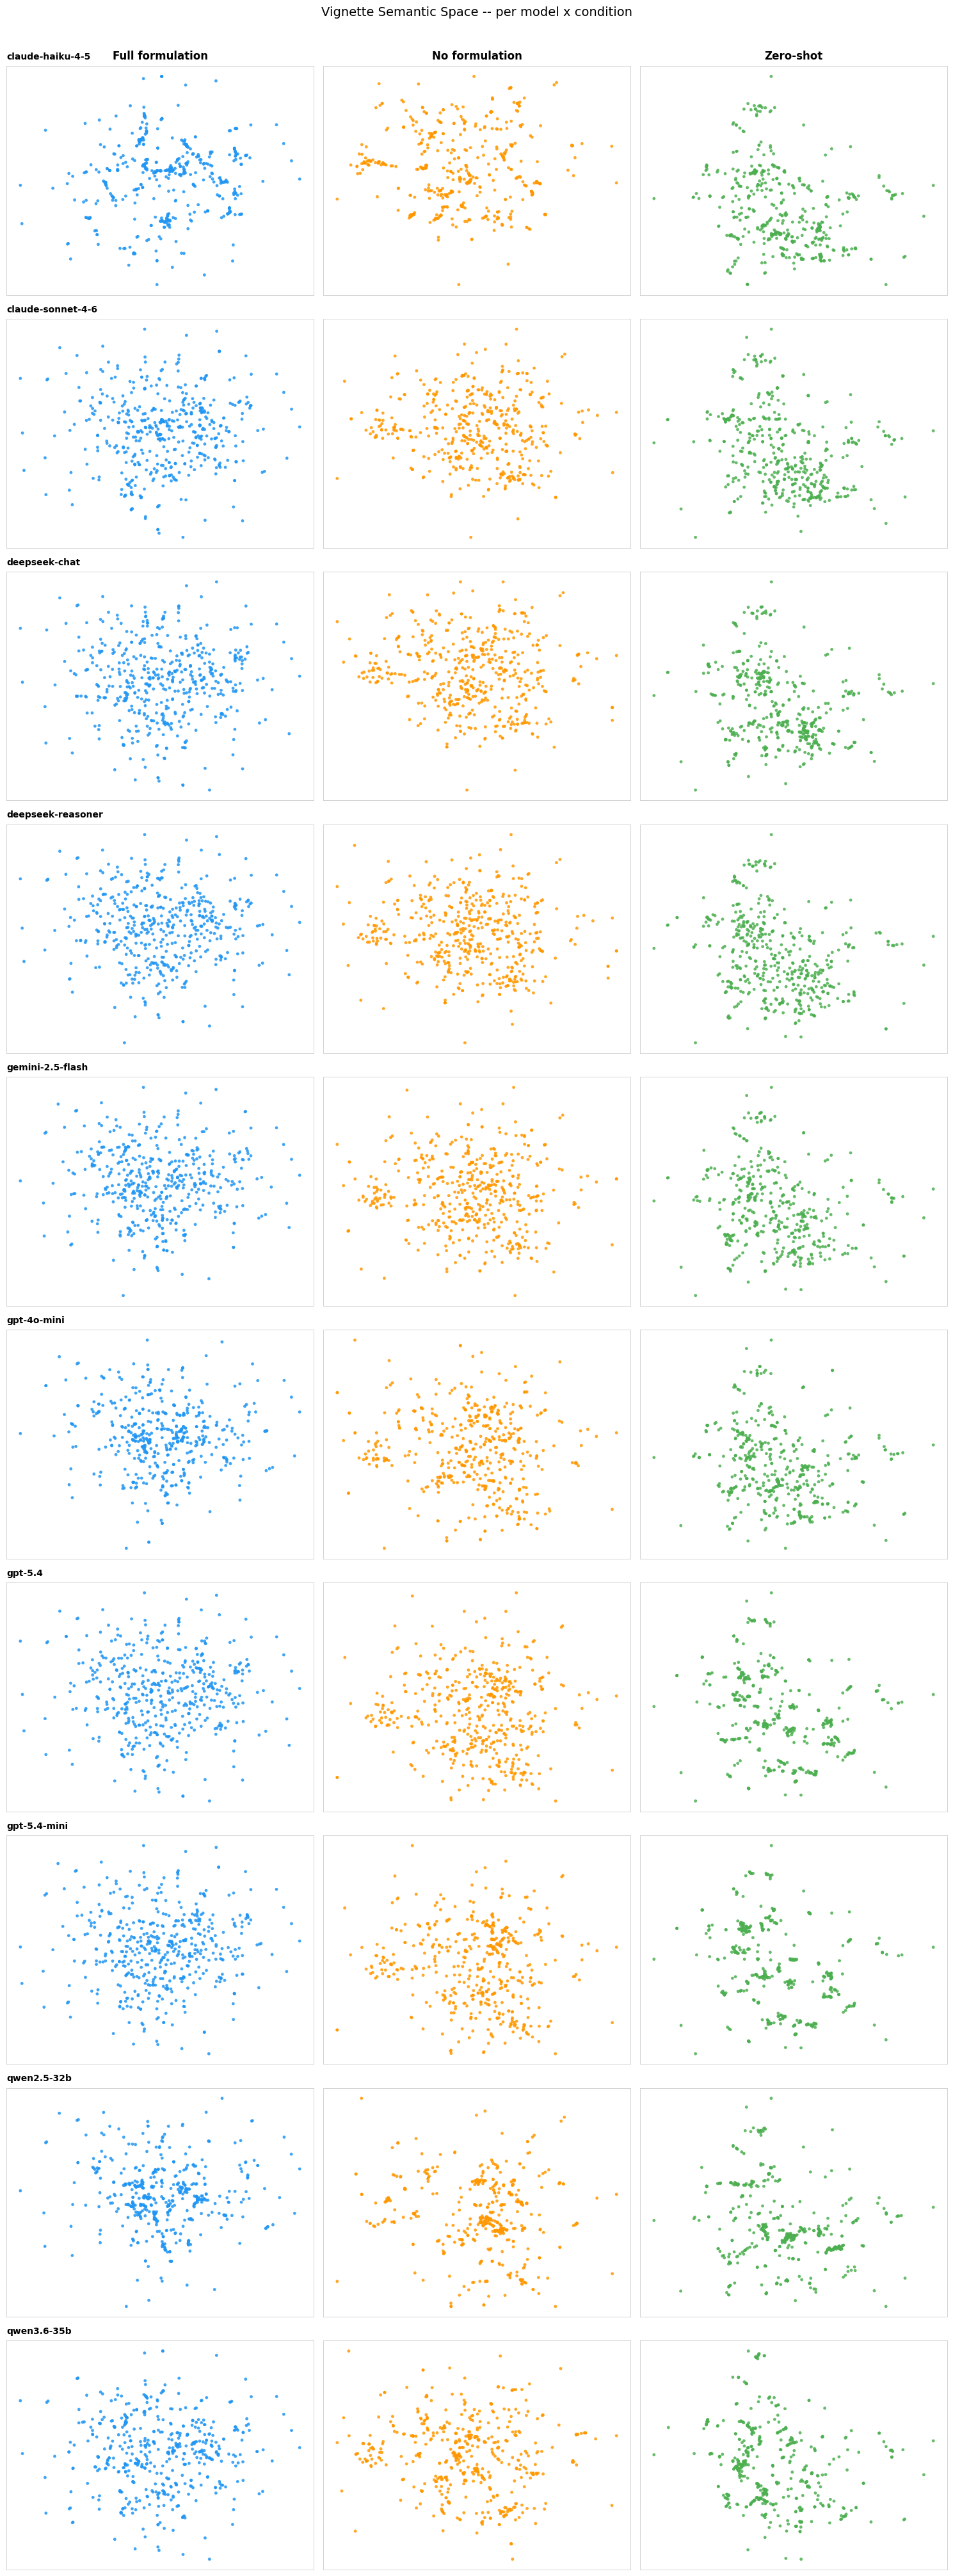

Saved -> ..\data\analysis/umap_per_model_grid.png


In [97]:
models = sorted(df['model'].unique())
conditions = list(CONDITION_LABELS.keys())
nrows, ncols = len(models), len(conditions)

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 5, nrows * 4))

for r, model in enumerate(models):
    for c, cond in enumerate(conditions):
        ax = axes[r, c]

        idx        = df[df['condition'] == cond].index
        cond_df    = df.loc[idx].reset_index(drop=True)
        coords     = umap_coords[cond]
        model_mask = (cond_df['model'] == model).values

        ax.scatter(coords[model_mask, 0], coords[model_mask, 1],
                   c=CONDITION_COLORS[cond], s=12, alpha=0.85, edgecolors='none')

        ax.set_xticks([]); ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_linewidth(0.6)
            spine.set_color('#cccccc')

        # Condition label on top row
        if r == 0:
            ax.set_title(CONDITION_LABELS[cond], fontsize=12, fontweight='bold', pad=8)

        # Model name above leftmost cell of each row
        if c == 0:
            ax.set_title(model, loc='left', fontsize=10, fontweight='bold', pad=8)

plt.suptitle('Vignette Semantic Space -- per model x condition',
             fontsize=14, y=1.005)
plt.tight_layout()
plt.savefig(ANALYSIS_DIR / 'umap_per_model_grid.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved -> {ANALYSIS_DIR}/umap_per_model_grid.png')


In [98]:
from sklearn.manifold import TSNE

TSNE_CACHE = ANALYSIS_DIR / 'tsne_coords_per_condition.npz'

if TSNE_CACHE.exists():
    _c = np.load(TSNE_CACHE)
    tsne_coords = {k: _c[k] for k in _c.files}
    print('Loaded cached MiniLM t-SNE coords:', list(tsne_coords.keys()))
else:
    tsne_coords = {}
    for cond in CONDITION_LABELS:
        idx  = df[df['condition'] == cond].index.tolist()
        embs = embeddings[idx]
        print(f'{CONDITION_LABELS[cond]}: running t-SNE on {len(idx)} vignettes...')
        coords = TSNE(n_components=2, perplexity=30, learning_rate='auto',
                      init='pca', random_state=42, n_jobs=-1).fit_transform(embs)
        tsne_coords[cond] = coords
        print(f'  done {coords.shape}')
    np.savez(TSNE_CACHE, **tsne_coords)
    print(f'Saved -> {TSNE_CACHE}')


Loaded cached MiniLM t-SNE coords: ['full', 'no_formulation', 'zero_shot']


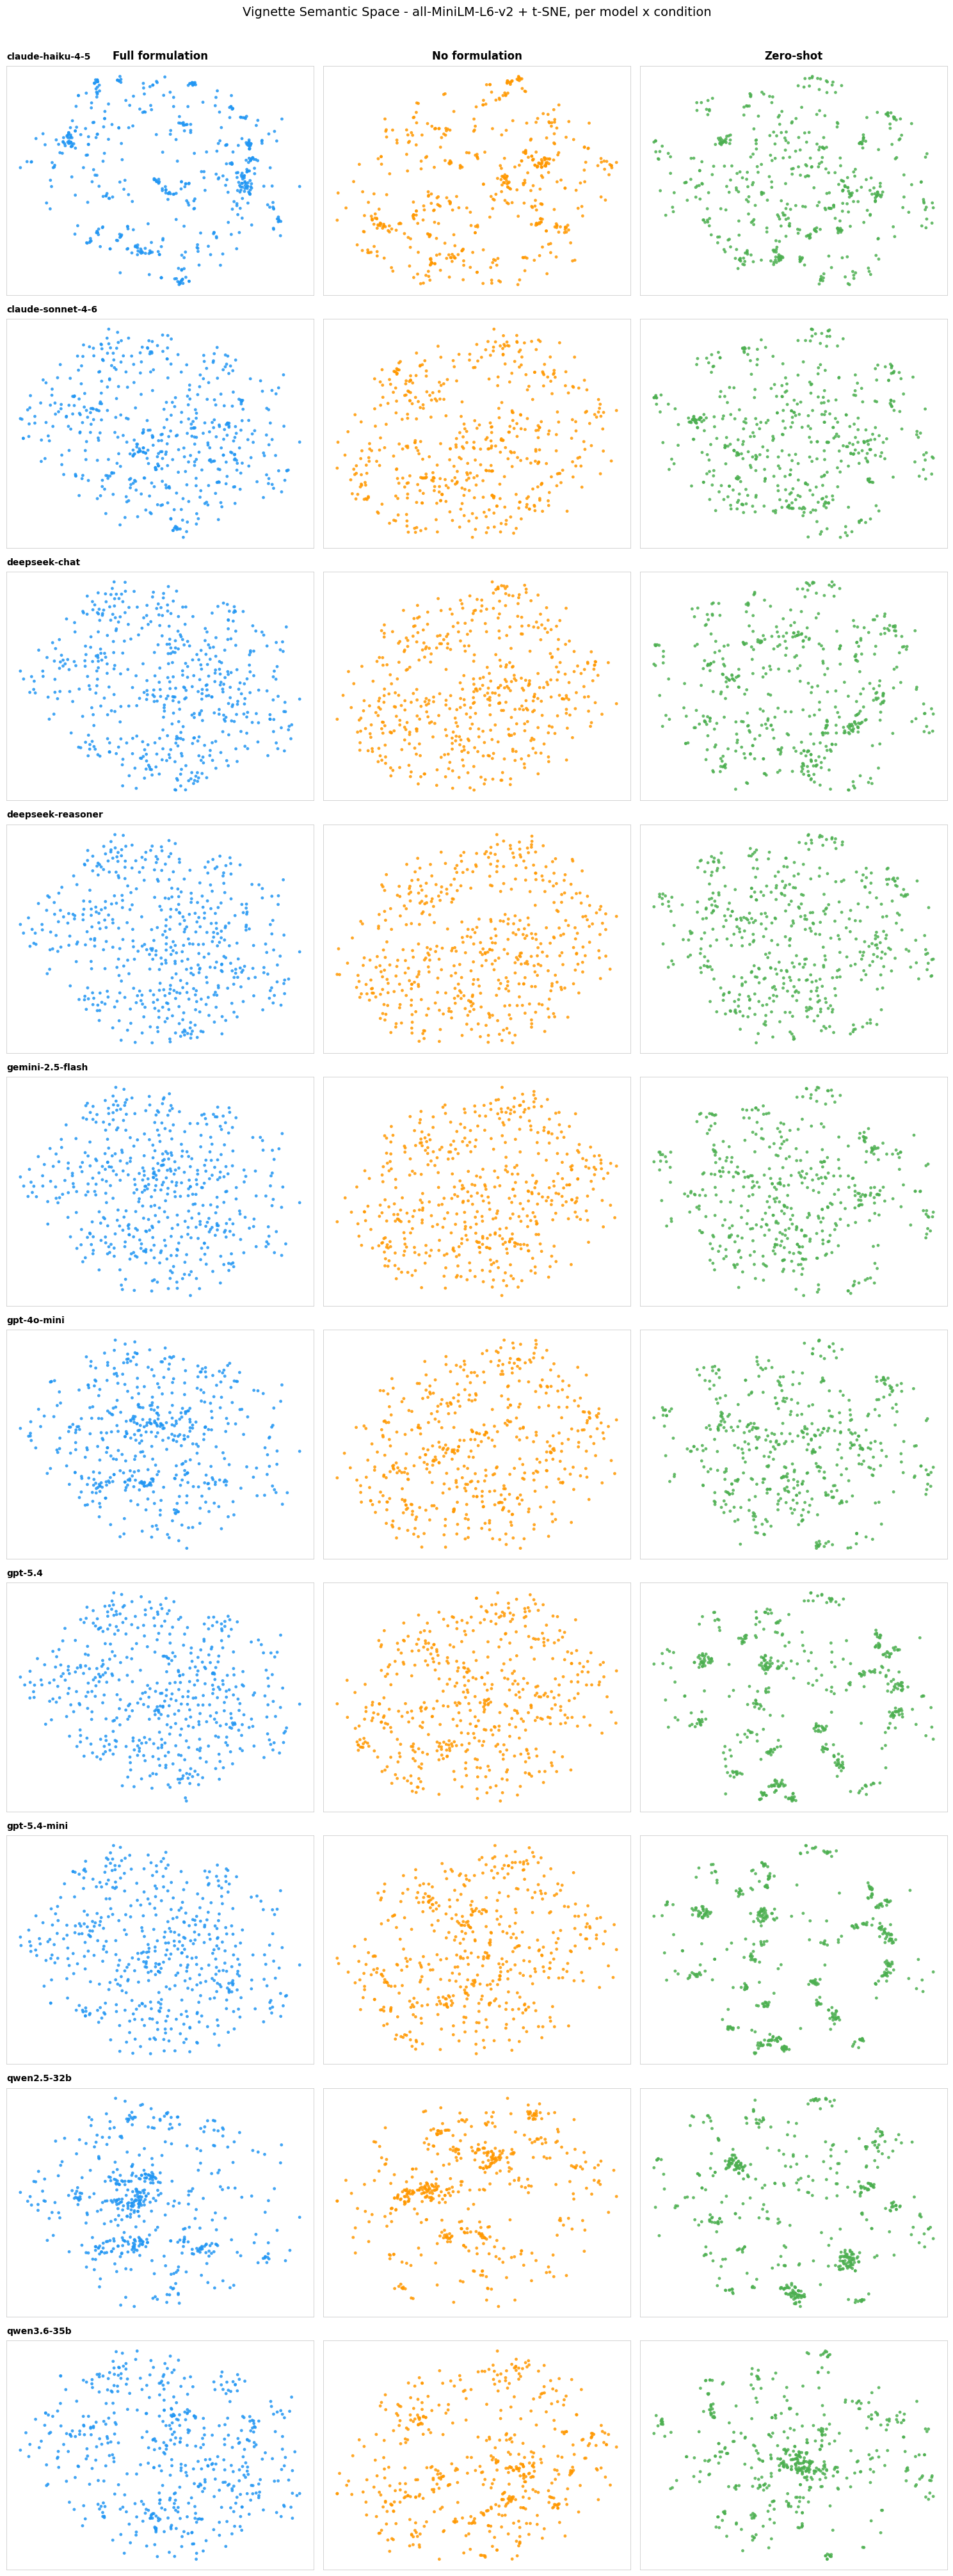

Saved -> ..\data\analysis/tsne_per_model_grid_minilm.png


In [99]:
# Grid: per model x condition - all-MiniLM-L6-v2 + t-SNE
models     = sorted(df['model'].unique())
conditions = list(CONDITION_LABELS.keys())
nrows, ncols = len(models), len(conditions)

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 5, nrows * 4))

for r, model in enumerate(models):
    for c, cond in enumerate(conditions):
        ax = axes[r, c]

        idx        = df[df['condition'] == cond].index
        cond_df    = df.loc[idx].reset_index(drop=True)
        coords     = tsne_coords[cond]
        model_mask = (cond_df['model'] == model).values

        ax.scatter(coords[model_mask, 0], coords[model_mask, 1],
                   c=CONDITION_COLORS[cond], s=12, alpha=0.85, edgecolors='none')

        ax.set_xticks([]); ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_linewidth(0.6)
            spine.set_color('#cccccc')

        if r == 0:
            ax.set_title(CONDITION_LABELS[cond], fontsize=12, fontweight='bold', pad=8)

        if c == 0:
            ax.set_title(model, loc='left', fontsize=10, fontweight='bold', pad=8)

plt.suptitle('Vignette Semantic Space - all-MiniLM-L6-v2 + t-SNE, per model x condition',
             fontsize=14, y=1.005)
plt.tight_layout()
plt.savefig(ANALYSIS_DIR / 'tsne_per_model_grid_minilm.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved -> {ANALYSIS_DIR}/tsne_per_model_grid_minilm.png')


### 5b. Colored by persona

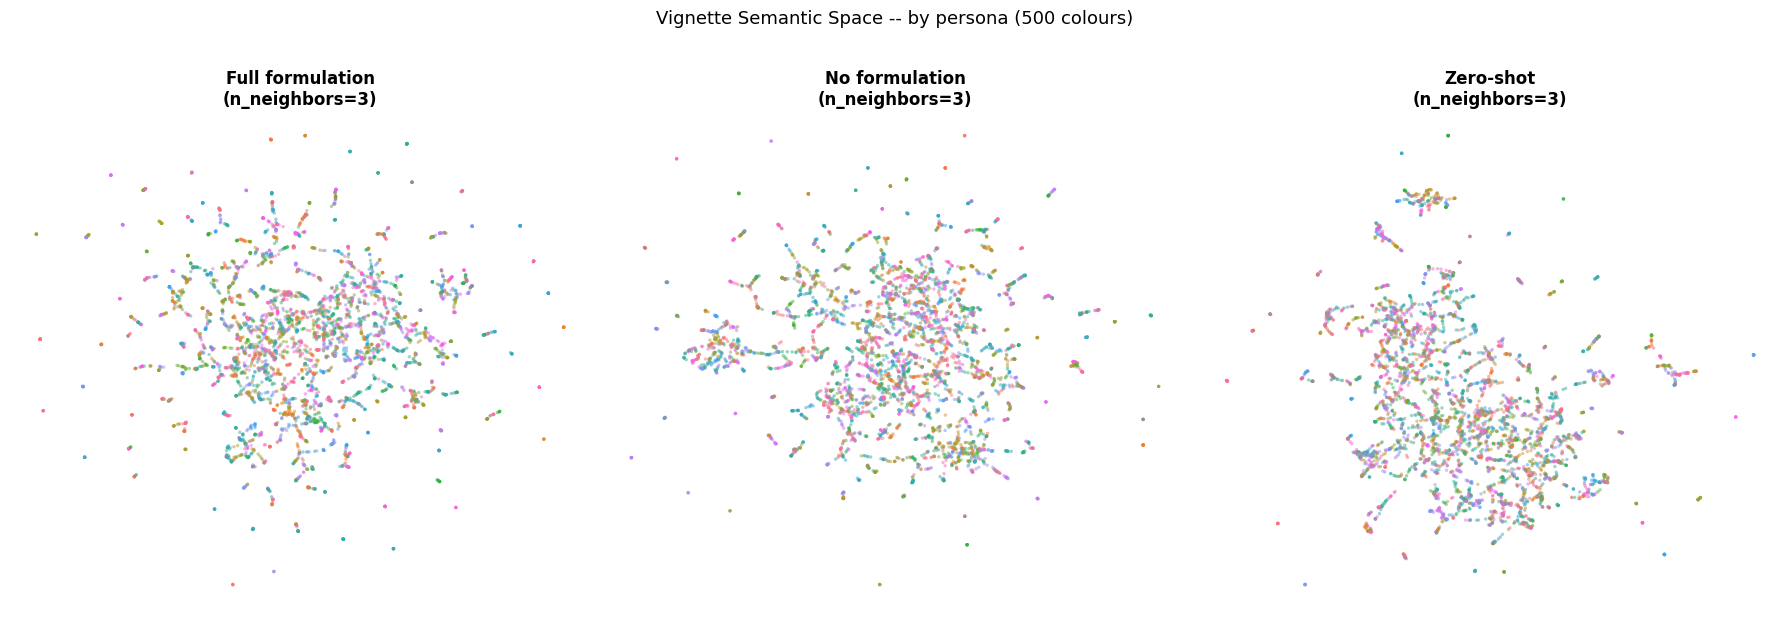

In [85]:
persona_ids   = sorted(df["persona_id"].unique())
persona_color = dict(zip(persona_ids,
                         sns.color_palette("husl", n_colors=len(persona_ids))))

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, cond in zip(axes, CONDITION_LABELS):
    idx     = df[df["condition"] == cond].index
    cond_df = df.loc[idx].reset_index(drop=True)
    coords  = umap_coords[cond]
    best_n  = neighbor_info[cond]["best_n"]
    ax.scatter(coords[:, 0], coords[:, 1],
               c=[persona_color[p] for p in cond_df["persona_id"]],
               s=6, alpha=0.5, edgecolors="none")
    ax.set_title(f"{CONDITION_LABELS[cond]}\n(n_neighbors={best_n})",
                 fontsize=12, fontweight="bold")
    ax.set_xticks([]); ax.set_yticks([])
    ax.spines[["top", "right", "left", "bottom"]].set_visible(False)
plt.suptitle("Vignette Semantic Space -- by persona (500 colours)",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(ANALYSIS_DIR / "umap_by_condition_persona.png", dpi=150, bbox_inches="tight")
plt.show()


## 6. Semantic diversity metrics
### 6a. Mean pairwise cosine distance per condition
Computed in the **original embedding space** (independent of UMAP parameters).
Higher = vignettes more semantically diverse.

In [86]:
diversity_rows = []
for cond in CONDITION_LABELS:
    idx  = df[df["condition"] == cond].index
    embs = embeddings[idx]
    print(f"{CONDITION_LABELS[cond]}: {len(idx)}x{len(idx)} distance matrix...")
    dists = pairwise_distances(embs, metric="cosine")
    upper = dists[np.triu_indices_from(dists, k=1)]
    diversity_rows.append({
        "condition":            cond,
        "label":                CONDITION_LABELS[cond],
        "n":                    len(idx),
        "mean_pairwise_dist":   round(float(upper.mean()), 4),
        "std_pairwise_dist":    round(float(upper.std()),  4),
        "median_pairwise_dist": round(float(np.median(upper)), 4),
    })
    print(f"  mean={upper.mean():.4f}  sd={upper.std():.4f}")

diversity_df = pd.DataFrame(diversity_rows)
diversity_df[["label", "n", "mean_pairwise_dist", "std_pairwise_dist"]]


Full formulation: 4998x4998 distance matrix...
  mean=0.3722  sd=0.0841
No formulation: 4999x4999 distance matrix...
  mean=0.3924  sd=0.0868
Zero-shot: 4984x4984 distance matrix...
  mean=0.4399  sd=0.0942


,label,n,mean_pairwise_dist,std_pairwise_dist
0,Full formulation,4998,0.3722,0.0841
1,No formulation,4999,0.3924,0.0868
2,Zero-shot,4984,0.4399,0.0942


### 6b. Silhouette scores
- **S_model**: do models produce distinct vignettes within a condition?
- **S_persona**: does persona drive semantic content?

Near +1 -> label predicts clusters. Near 0 -> interleaved.

In [87]:
sil_rows = []
for cond in CONDITION_LABELS:
    idx      = df[df["condition"] == cond].index
    embs     = embeddings[idx]
    labels_m = LabelEncoder().fit_transform(df.loc[idx, "model"])
    labels_p = LabelEncoder().fit_transform(df.loc[idx, "persona_id"])
    s_m = silhouette_score(embs, labels_m, metric="cosine")
    s_p = silhouette_score(embs, labels_p, metric="cosine")
    sil_rows.append({"condition": cond, "label": CONDITION_LABELS[cond],
                     "silhouette_by_model": round(s_m, 4),
                     "silhouette_by_persona": round(s_p, 4)})
    print(f"{CONDITION_LABELS[cond]:<22}  S_model={s_m:.4f}  S_persona={s_p:.4f}")

sil_df = pd.DataFrame(sil_rows)


Full formulation        S_model=-0.0045  S_persona=0.1195
No formulation          S_model=-0.0001  S_persona=0.0929
Zero-shot               S_model=0.0139  S_persona=0.0660


### 6c. Summary table + save

In [88]:
summary = diversity_df.merge(sil_df, on=["condition", "label"])
summary = summary[["label", "n", "mean_pairwise_dist", "std_pairwise_dist",
                    "silhouette_by_model", "silhouette_by_persona"]]
summary.columns = ["Condition", "N", "Mean pairwise dist", "SD",
                   "Silhouette (model)", "Silhouette (persona)"]
summary = summary.set_index("Condition")
summary.to_csv(ANALYSIS_DIR / "diversity_summary.csv")
print(f"Saved -> {ANALYSIS_DIR / 'diversity_summary.csv'}")
summary.round(4)


Saved -> ..\data\analysis\diversity_summary.csv


,N,Mean pairwise dist,SD,Silhouette (model),Silhouette (persona)
Condition,,,,,
Full formulation,4998,0.3722,0.0841,-0.0045,0.1195
No formulation,4999,0.3924,0.0868,-0.0001,0.0929
Zero-shot,4984,0.4399,0.0942,0.0139,0.0660


### 6f. Per-model diversity — pivot table & heatmap

In [89]:
# Pivot table: model x condition
pivot = pm_df.pivot(index="model", columns="label", values="mean_dist")
pivot = pivot[[CONDITION_LABELS[c] for c in CONDITION_LABELS]]  # fix column order
pivot["mean_across_conditions"] = pivot.mean(axis=1)
pivot = pivot.sort_values("mean_across_conditions", ascending=False)
pivot.to_csv(ANALYSIS_DIR / "diversity_per_model_pivot.csv")
pivot.round(4)


label,Full formulation,No formulation,Zero-shot,mean_across_conditions
model,,,,
claude-sonnet-4-6,0.6004,0.6390,0.6270,0.6221
claude-haiku-4-5,0.6274,0.6395,0.5877,0.6182
deepseek-reasoner,0.5735,0.5868,0.5881,0.5828
deepseek-chat,0.5694,0.5849,0.5416,0.5653
qwen3.6-35b,0.5377,0.5597,0.5534,0.5503
gemini-2.5-flash,0.5049,0.5153,0.5844,0.5349
gpt-5.4,0.5683,0.5504,0.4741,0.5309
qwen2.5-32b,0.4746,0.5107,0.5571,0.5141
gpt-4o-mini,0.4809,0.5087,0.5512,0.5136


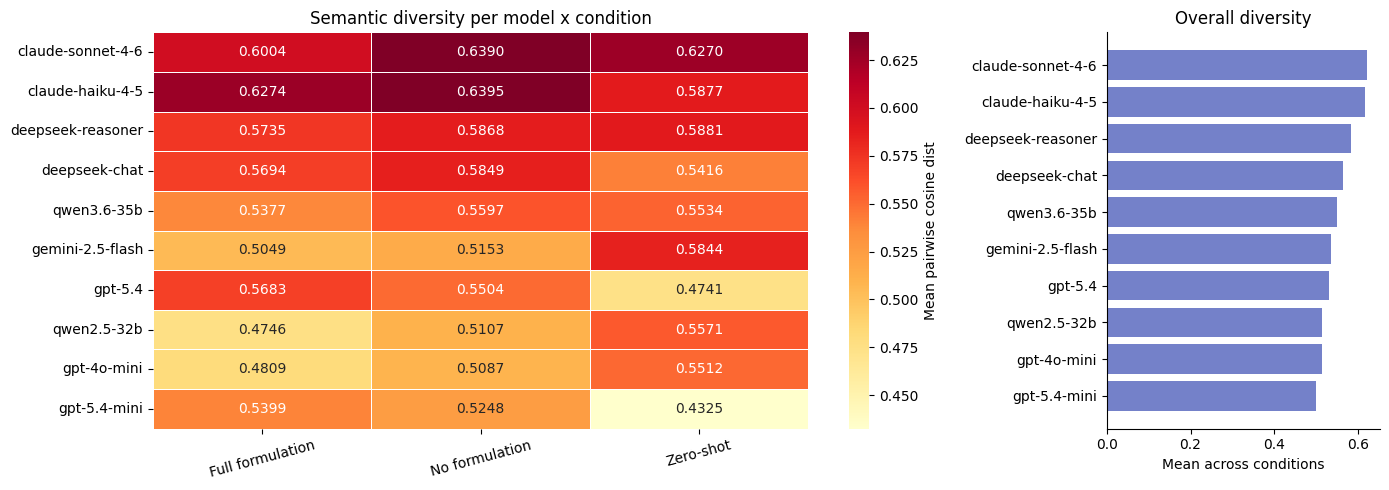

Saved -> ..\data\analysis\diversity_per_model_heatmap.png


In [90]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), gridspec_kw={"width_ratios": [3, 1]})

# Heatmap: model x condition
data = pivot[[CONDITION_LABELS[c] for c in CONDITION_LABELS]]
sns.heatmap(data, ax=axes[0], annot=True, fmt=".4f", cmap="YlOrRd",
            linewidths=0.5, cbar_kws={"label": "Mean pairwise cosine dist"})
axes[0].set_title("Semantic diversity per model x condition", fontsize=12)
axes[0].set_xlabel("")
axes[0].set_ylabel("")
axes[0].tick_params(axis="x", rotation=15)

# Bar: mean across conditions per model
axes[1].barh(pivot.index, pivot["mean_across_conditions"],
             color="#5C6BC0", alpha=0.85)
axes[1].set_xlabel("Mean across conditions", fontsize=10)
axes[1].set_title("Overall diversity", fontsize=12)
axes[1].spines[["top", "right"]].set_visible(False)
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig(ANALYSIS_DIR / "diversity_per_model_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved -> {ANALYSIS_DIR / 'diversity_per_model_heatmap.png'}")


## 7. Inter-model agreement per persona
For each persona × condition, compute the mean pairwise cosine distance
**across all models** that generated a vignette for that persona.

- **Low distance** → models agree on content → the formulation is driving the text
- **High distance** → models diverge → each model invents its own narrative

If the E&C formulation works as intended, full formulation should show the
**lowest** inter-model distance (highest agreement) across personas.

In [91]:
# For each persona x condition: compute mean pairwise cosine distance
# across all models that have a vignette for that persona.
# Low distance = models agree on content -> formulation is driving the text.
# High distance = models diverge -> each model invents its own narrative.

from sklearn.metrics import pairwise_distances

agreement_rows = []

personas = sorted(df["persona_id"].dropna().unique())

for cond in CONDITION_LABELS:
    cond_df = df[df["condition"] == cond]
    for pid in personas:
        sub = cond_df[cond_df["persona_id"] == pid]
        if len(sub) < 2:
            continue
        embs  = embeddings[sub.index]
        dists = pairwise_distances(embs, metric="cosine")
        upper = dists[np.triu_indices_from(dists, k=1)]
        agreement_rows.append({
            "condition":    cond,
            "label":        CONDITION_LABELS[cond],
            "persona_id":   pid,
            "n_models":     len(sub),
            "mean_dist":    upper.mean(),   # low = models agree
            "std_dist":     upper.std(),
        })

agree_df = pd.DataFrame(agreement_rows)
agree_df.to_csv(ANALYSIS_DIR / "inter_model_agreement.csv", index=False)

# Summary per condition
summary = agree_df.groupby("label")["mean_dist"].agg(["mean","std","median"])
summary.columns = ["mean", "std", "median"]
print("Inter-model distance per condition (lower = more agreement):")
print(summary.round(4))


Inter-model distance per condition (lower = more agreement):
                    mean     std  median
label                                   
Full formulation  0.2094  0.0278  0.2061
No formulation    0.2263  0.0283  0.2257
Zero-shot         0.2423  0.0289  0.2434


## 8. DSM-5 / E&C component cosine-similarity coverage
For each vignette we compute the **dot product** (= cosine similarity for L2-normalised
vectors) against 9 short clinical query strings: 4 DSM-5 symptom clusters and 5 Ehlers &
Clark (2000) components. A vignette *covers* a dimension when its similarity exceeds a
threshold (default 0.25).

Key question: does adding clinical structure (full formulation) increase coverage of
relevant clinical content compared with zero-shot?


In [92]:
from sentence_transformers import SentenceTransformer

QUERIES = {
    # DSM-5 symptom clusters
    "DSM-5: Re-experiencing":        "intrusive memories, flashbacks, nightmares about the trauma",
    "DSM-5: Avoidance":              "avoiding trauma reminders, places, people, thoughts and feelings",
    "DSM-5: Neg. cognitions & mood": "guilt, shame, distorted beliefs, emotional numbing, estrangement",
    "DSM-5: Hyperarousal":           "hypervigilance, sleep problems, irritability, exaggerated startle",
    # E&C (2000) components
    "E&C: Trauma memory":            "fragmented trauma memory, gaps, poor contextualisation, sensory intrusions",
    "E&C: Negative appraisals":      "catastrophic personal meaning, self-blame, permanent change",
    "E&C: Triggers":                 "situational and internal cues that activate trauma memory",
    "E&C: Current threat":           "sense of ongoing danger, mental defeat, threat not yet in the past",
    "E&C: Maladaptive coping":       "thought suppression, rumination, substance use, safety behaviours",
}

_enc = SentenceTransformer('all-MiniLM-L6-v2')
query_embs = _enc.encode(
    list(QUERIES.values()),
    normalize_embeddings=True,
    show_progress_bar=False,
)  # shape: (9, 384)

query_labels = list(QUERIES.keys())
print(f"Query embeddings: {query_embs.shape}")


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Query embeddings: (9, 384)


In [100]:
# dot product == cosine similarity (embeddings already L2-normalised)
sims = embeddings @ query_embs.T   # (n_vignettes, 9)
print(f"Similarity matrix: {sims.shape}  min={sims.min():.3f}  max={sims.max():.3f}")

sim_df = df[['persona_id', 'model', 'condition']].copy()
for i, lbl in enumerate(query_labels):
    sim_df[lbl] = sims[:, i]

THRESHOLD = 0.25
print(f"\nCoverage rate (sim > {THRESHOLD}) per condition:")
for cond, lbl in CONDITION_LABELS.items():
    sub = sim_df[sim_df['condition'] == cond]
    rates = {q: (sub[q] > THRESHOLD).mean() for q in query_labels}
    avg   = sum(rates.values()) / len(rates)
    print(f"  {lbl:<22}  avg_coverage={avg:.3f}")


ValueError: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 384 is different from 768)

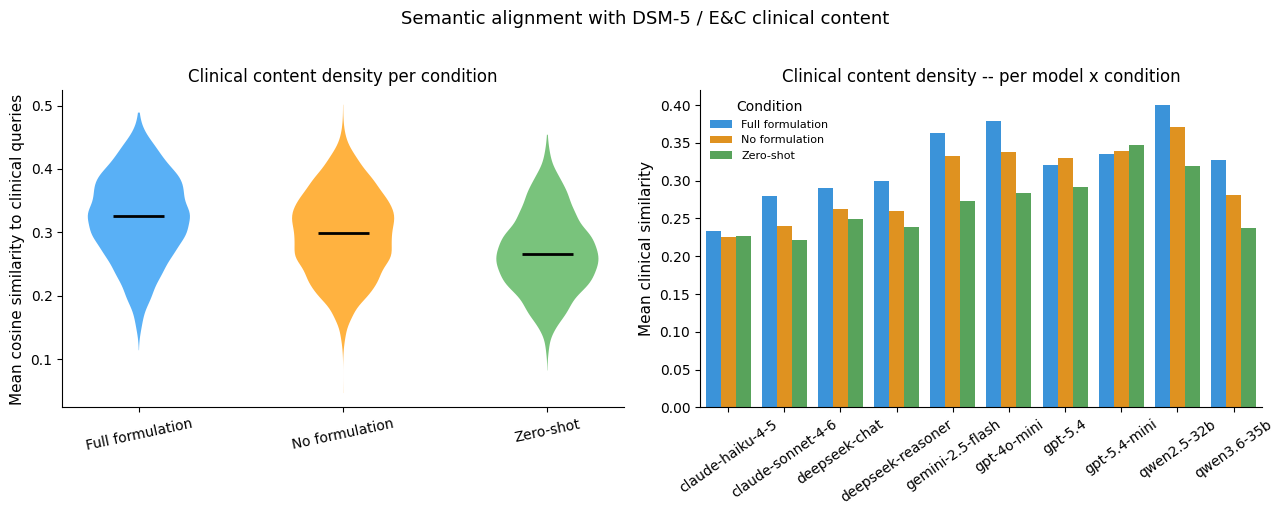

Saved -> ..\data\analysis/clinical_content_density.png


In [ ]:
sim_df['mean_clinical_sim'] = sim_df[query_labels].mean(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Violin of mean clinical similarity
ax = axes[0]
order = list(CONDITION_LABELS.values())
data_v = [sim_df[sim_df['condition'] == c]['mean_clinical_sim'].values
          for c in CONDITION_LABELS]
parts = ax.violinplot(data_v, positions=range(len(order)),
                      showmedians=True, showextrema=False)
for pc, cond in zip(parts['bodies'], CONDITION_LABELS):
    pc.set_facecolor(CONDITION_COLORS[cond])
    pc.set_alpha(0.75)
parts['cmedians'].set_color('black')
parts['cmedians'].set_linewidth(2)
ax.set_xticks(range(len(order)))
ax.set_xticklabels(order, rotation=12)
ax.set_ylabel('Mean cosine similarity to clinical queries', fontsize=11)
ax.set_title('Clinical content density per condition', fontsize=12)
ax.spines[['top', 'right']].set_visible(False)

# Per-model mean clinical sim
ax = axes[1]
pm_sim = (sim_df.groupby(['model', 'condition'])['mean_clinical_sim']
          .mean().reset_index())
pm_sim['label'] = pm_sim['condition'].map(CONDITION_LABELS)
sns.barplot(data=pm_sim, x='model', y='mean_clinical_sim', hue='label',
            palette=[CONDITION_COLORS[c] for c in CONDITION_LABELS], ax=ax)
ax.set_xlabel('')
ax.set_ylabel('Mean clinical similarity', fontsize=11)
ax.set_title('Clinical content density -- per model x condition', fontsize=12)
ax.tick_params(axis='x', rotation=35)
ax.legend(title='Condition', frameon=False, fontsize=8)
ax.spines[['top', 'right']].set_visible(False)

plt.suptitle('Semantic alignment with DSM-5 / E&C clinical content', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(ANALYSIS_DIR / 'clinical_content_density.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved -> {ANALYSIS_DIR}/clinical_content_density.png')


---
## 11. all-mpnet-base-v2 embeddings
110M parameter model, 768-d, stronger semantic distinctions than all-MiniLM-L6-v2.
Same pipeline as MiniLM. All results cached; delete files to recompute.

In [ ]:
from sentence_transformers import SentenceTransformer

MPNET_EMB_CACHE = ANALYSIS_DIR / 'embeddings_mpnet.npy'

if MPNET_EMB_CACHE.exists():
    mpnet_embeddings = np.load(MPNET_EMB_CACHE)
    print(f'Loaded cached mpnet embeddings: {mpnet_embeddings.shape}')
    assert len(mpnet_embeddings) == len(df), 'Cache mismatch -- delete and rerun'
else:
    print(f'Computing mpnet embeddings for {len(df)} vignettes...')
    _enc = SentenceTransformer('all-mpnet-base-v2')
    mpnet_embeddings = _enc.encode(
        df['vignette'].tolist(),
        show_progress_bar=True,
        batch_size=32,
        normalize_embeddings=True,
    )
    np.save(MPNET_EMB_CACHE, mpnet_embeddings)
    print(f'Saved -> {MPNET_EMB_CACHE}  shape={mpnet_embeddings.shape}')


Computing mpnet embeddings for 14981 vignettes...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/469 [00:00<?, ?it/s]

Saved -> ..\data\analysis\embeddings_mpnet.npy  shape=(14981, 768)


In [ ]:
import umap
from sklearn.manifold import trustworthiness

MPNET_NEIGHBOR_CACHE  = ANALYSIS_DIR / 'neighbor_selection_mpnet.json'
MPNET_UMAP_COND_CACHE = ANALYSIS_DIR / 'umap_coords_per_condition_mpnet.npz'
MPNET_CANDIDATES      = [5, 8, 10, 15, 20, 30]

# ── Neighbor selection ────────────────────────────────────────────────────────
if MPNET_NEIGHBOR_CACHE.exists():
    with open(MPNET_NEIGHBOR_CACHE) as f:
        mpnet_neighbor_info = json.load(f)
    print('Loaded cached mpnet neighbor selection:')
else:
    mpnet_neighbor_info = {}
    for cond in CONDITION_LABELS:
        idx   = df[df['condition'] == cond].index.tolist()
        embs  = mpnet_embeddings[idx]
        cands = [k for k in MPNET_CANDIDATES if k < len(idx)]
        print(f'\n{CONDITION_LABELS[cond]}  ({len(idx)} vignettes)')
        scores = {}
        for k in cands:
            coords = umap.UMAP(n_components=2, n_neighbors=k,
                               min_dist=0.1, random_state=42).fit_transform(embs)
            t = trustworthiness(embs, coords, n_neighbors=k)
            c = trustworthiness(coords, embs, n_neighbors=k)
            combined = (t + c) / 2
            scores[str(k)] = round(combined, 4)
            print(f'  k={k:2d}  mean(T+C)/2={combined:.4f}')
        best_n = max(scores, key=lambda k: scores[k])
        mpnet_neighbor_info[cond] = {'best_n': int(best_n), 'scores': scores}
        print(f'  -> selected k={best_n}')
    with open(MPNET_NEIGHBOR_CACHE, 'w') as f:
        json.dump(mpnet_neighbor_info, f, indent=2)
    print(f'Saved -> {MPNET_NEIGHBOR_CACHE}')

for cond, info in mpnet_neighbor_info.items():
    print(f'  {CONDITION_LABELS[cond]:<22}  best_n = {info["best_n"]}')

# ── UMAP projections ──────────────────────────────────────────────────────────
if MPNET_UMAP_COND_CACHE.exists():
    _c = np.load(MPNET_UMAP_COND_CACHE)
    mpnet_umap_cond = {k: _c[k] for k in _c.files}
    print('Loaded cached mpnet UMAP coords:', list(mpnet_umap_cond.keys()))
else:
    mpnet_umap_cond = {}
    for cond in CONDITION_LABELS:
        idx    = df[df['condition'] == cond].index.tolist()
        embs   = mpnet_embeddings[idx]
        best_n = mpnet_neighbor_info[cond]['best_n']
        print(f'{CONDITION_LABELS[cond]}: n_neighbors={best_n}, {len(idx)} vignettes...')
        coords = umap.UMAP(n_components=2, n_neighbors=best_n,
                           min_dist=0.1, random_state=42).fit_transform(embs)
        mpnet_umap_cond[cond] = coords
        print(f'  done {coords.shape}')
    np.savez(MPNET_UMAP_COND_CACHE, **mpnet_umap_cond)
    print(f'Saved -> {MPNET_UMAP_COND_CACHE}')



Full formulation  (4998 vignettes)


c:\Users\amit\Documents\GitHub\vignette_crafter\venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  k= 5  mean(T+C)/2=0.9389


c:\Users\amit\Documents\GitHub\vignette_crafter\venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  k= 8  mean(T+C)/2=0.9205


...

  done (4998, 2)
No formulation: n_neighbors=5, 4999 vignettes...


c:\Users\amit\Documents\GitHub\vignette_crafter\venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  done (4999, 2)
Zero-shot: n_neighbors=5, 4984 vignettes...


c:\Users\amit\Documents\GitHub\vignette_crafter\venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  done (4984, 2)
Saved -> ..\data\analysis\umap_coords_per_condition_mpnet.npz


In [ ]:
from sklearn.manifold import TSNE

MPNET_TSNE_CACHE = ANALYSIS_DIR / 'tsne_coords_per_condition_mpnet.npz'

if MPNET_TSNE_CACHE.exists():
    _c = np.load(MPNET_TSNE_CACHE)
    mpnet_tsne_cond = {k: _c[k] for k in _c.files}
    print('Loaded cached mpnet t-SNE coords:', list(mpnet_tsne_cond.keys()))
else:
    mpnet_tsne_cond = {}
    for cond in CONDITION_LABELS:
        idx  = df[df['condition'] == cond].index.tolist()
        embs = mpnet_embeddings[idx]
        print(f'{CONDITION_LABELS[cond]}: running t-SNE on {len(idx)} vignettes...')
        coords = TSNE(n_components=2, perplexity=30, learning_rate='auto',
                      init='pca', random_state=42, n_jobs=-1).fit_transform(embs)
        mpnet_tsne_cond[cond] = coords
        print(f'  done {coords.shape}')
    np.savez(MPNET_TSNE_CACHE, **mpnet_tsne_cond)
    print(f'Saved -> {MPNET_TSNE_CACHE}')


Full formulation: running t-SNE on 4998 vignettes...
  done (4998, 2)
No formulation: running t-SNE on 4999 vignettes...
  done (4999, 2)
Zero-shot: running t-SNE on 4984 vignettes...
  done (4984, 2)
Saved -> ..\data\analysis\tsne_coords_per_condition_mpnet.npz


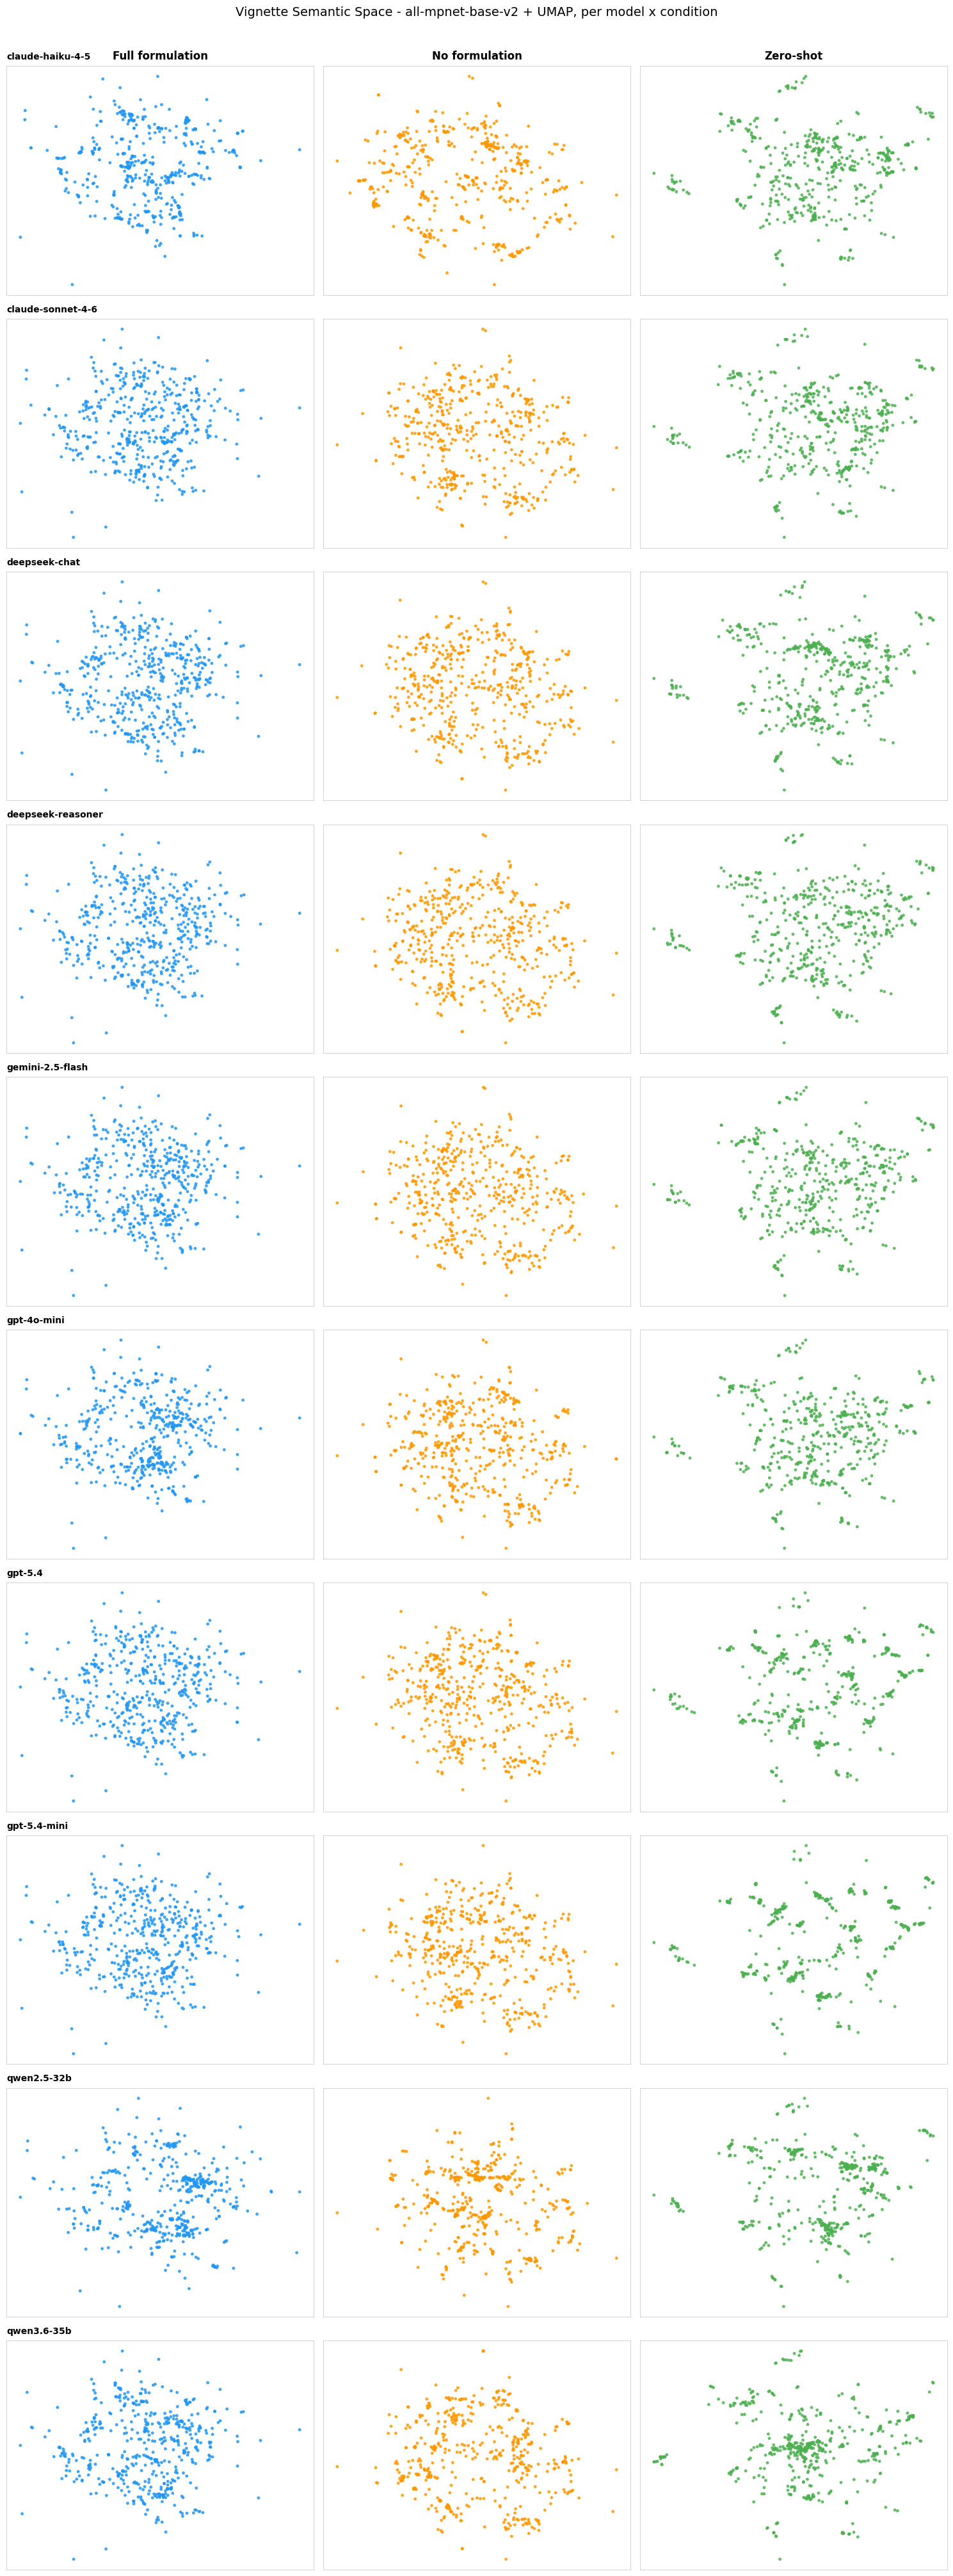

Saved -> ..\data\analysis/umap_per_model_grid_mpnet.png


In [ ]:
# Grid: per model x condition - all-mpnet-base-v2 + UMAP
models     = sorted(df['model'].unique())
conditions = list(CONDITION_LABELS.keys())
nrows, ncols = len(models), len(conditions)

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 5, nrows * 4))
for r, model in enumerate(models):
    for c, cond in enumerate(conditions):
        ax = axes[r, c]
        idx        = df[df['condition'] == cond].index
        cond_df    = df.loc[idx].reset_index(drop=True)
        coords     = mpnet_umap_cond[cond]
        model_mask = (cond_df['model'] == model).values
        ax.scatter(coords[model_mask, 0], coords[model_mask, 1],
                   c=CONDITION_COLORS[cond], s=12, alpha=0.85, edgecolors='none')
        ax.set_xticks([]); ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_visible(True); spine.set_linewidth(0.6); spine.set_color('#cccccc')
        if r == 0:
            ax.set_title(CONDITION_LABELS[cond], fontsize=12, fontweight='bold', pad=8)
        if c == 0:
            ax.set_title(model, loc='left', fontsize=10, fontweight='bold', pad=8)

plt.suptitle('Vignette Semantic Space - all-mpnet-base-v2 + UMAP, per model x condition',
             fontsize=14, y=1.005)
plt.tight_layout()
plt.savefig(ANALYSIS_DIR / 'umap_per_model_grid_mpnet.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved -> {ANALYSIS_DIR}/umap_per_model_grid_mpnet.png')


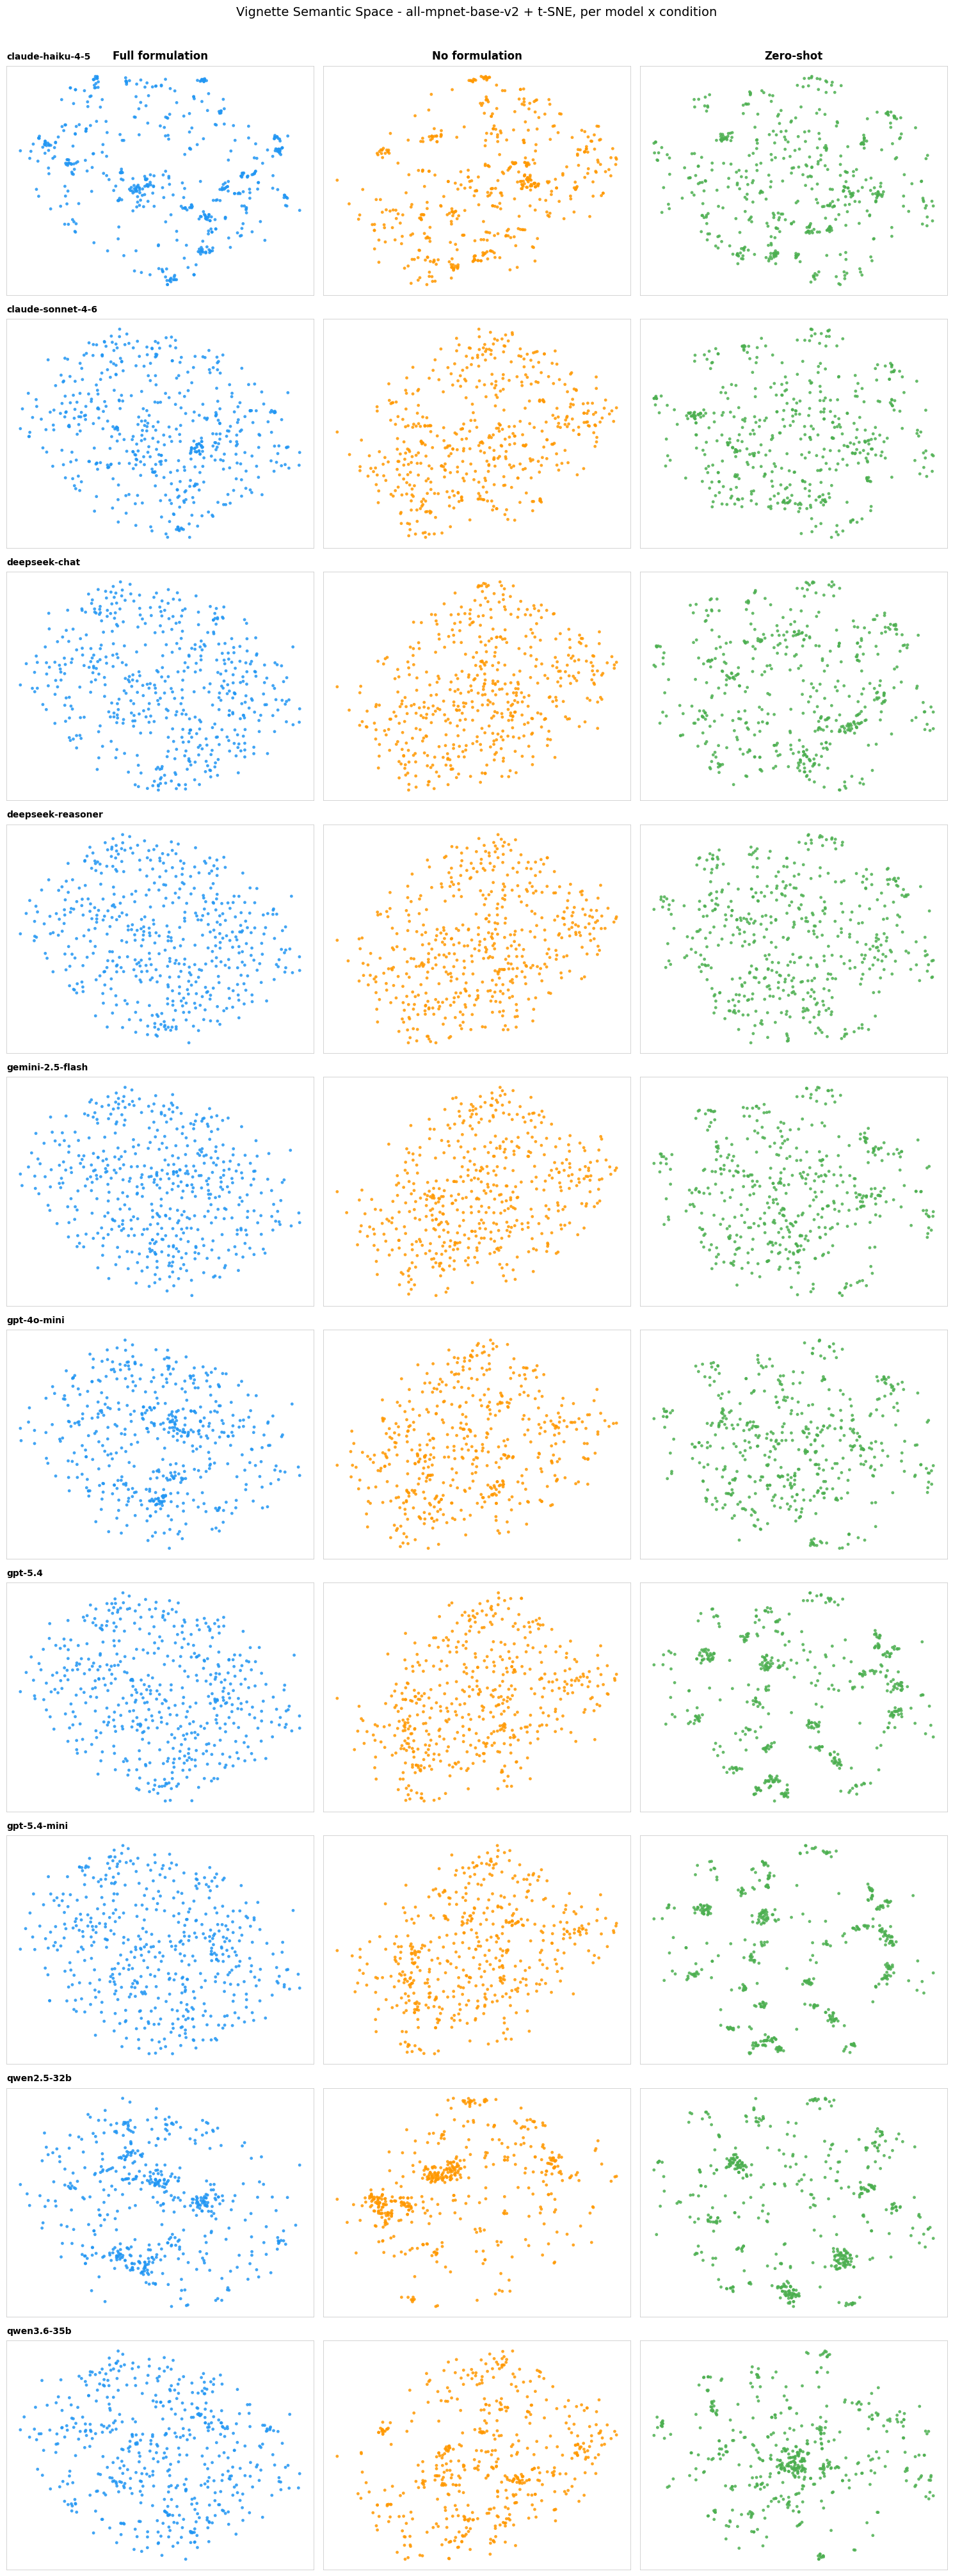

Saved -> ..\data\analysis/tsne_per_model_grid_mpnet.png


In [ ]:
# Grid: per model x condition - all-mpnet-base-v2 + t-SNE
models     = sorted(df['model'].unique())
conditions = list(CONDITION_LABELS.keys())
nrows, ncols = len(models), len(conditions)

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 5, nrows * 4))
for r, model in enumerate(models):
    for c, cond in enumerate(conditions):
        ax = axes[r, c]
        idx        = df[df['condition'] == cond].index
        cond_df    = df.loc[idx].reset_index(drop=True)
        coords     = mpnet_tsne_cond[cond]
        model_mask = (cond_df['model'] == model).values
        ax.scatter(coords[model_mask, 0], coords[model_mask, 1],
                   c=CONDITION_COLORS[cond], s=12, alpha=0.85, edgecolors='none')
        ax.set_xticks([]); ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_visible(True); spine.set_linewidth(0.6); spine.set_color('#cccccc')
        if r == 0:
            ax.set_title(CONDITION_LABELS[cond], fontsize=12, fontweight='bold', pad=8)
        if c == 0:
            ax.set_title(model, loc='left', fontsize=10, fontweight='bold', pad=8)

plt.suptitle('Vignette Semantic Space - all-mpnet-base-v2 + t-SNE, per model x condition',
             fontsize=14, y=1.005)
plt.tight_layout()
plt.savefig(ANALYSIS_DIR / 'tsne_per_model_grid_mpnet.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved -> {ANALYSIS_DIR}/tsne_per_model_grid_mpnet.png')


## 7. Vendi Score (clustering-aware diversity)

Mean pairwise cosine distance cannot distinguish uniform spread from tight clusters that are far apart.
The **Vendi Score** (Friedman & Dieng, 2022) is the effective number of distinct vignettes —
it rewards even coverage and penalises clustering.
Computed as the exponential entropy of the eigenvalue distribution of the cosine similarity matrix.
Higher = more uniformly diverse.

In [94]:
def vendi_score(embs):
    """Vendi Score: exp(entropy of eigenvalues of normalised cosine similarity matrix)."""
    n = len(embs)
    K = embs @ embs.T          # cosine similarity (embs are already L2-normalised)
    K = K / n                  # normalise
    eigvals = np.linalg.eigvalsh(K)
    eigvals = eigvals[eigvals > 1e-10]   # drop numerical zeros
    eigvals /= eigvals.sum()             # ensure sums to 1
    entropy = -np.sum(eigvals * np.log(eigvals))
    return float(np.exp(entropy))

# ── Per condition ──
print(f"{'Condition':<20}  {'Vendi Score':>12}  {'Max possible':>13}")
print("-" * 50)
for cond, label in CONDITION_LABELS.items():
    idx  = df[df["condition"] == cond].index
    embs = embeddings[idx]
    vs   = vendi_score(embs)
    n    = len(idx)
    print(f"{label:<20}  {vs:>12.1f}  {n:>13d}")

print()

# ── Per model x condition ──
rows = []
for model in sorted(df["model"].unique()):
    for cond, label in CONDITION_LABELS.items():
        idx  = df[(df["model"] == model) & (df["condition"] == cond)].index
        embs = embeddings[idx]
        vs   = vendi_score(embs)
        rows.append({"model": model, "condition": label, "vendi_score": round(vs, 1)})

vendi_df = pd.DataFrame(rows)
pivot_v  = vendi_df.pivot(index="model", columns="condition", values="vendi_score")
pivot_v  = pivot_v[[CONDITION_LABELS[c] for c in CONDITION_LABELS]]
pivot_v["mean"] = pivot_v.mean(axis=1)
pivot_v  = pivot_v.sort_values("mean", ascending=False)
print(pivot_v.to_string())
pivot_v.to_csv(ANALYSIS_DIR / "vendi_per_model.csv")

Condition              Vendi Score   Max possible
--------------------------------------------------
Full formulation              10.6           4998
No formulation                11.7           4999
Zero-shot                     14.2           4984

condition          Full formulation  No formulation  Zero-shot       mean
model                                                                    
claude-haiku-4-5               11.4            12.9       11.6  11.966667
deepseek-reasoner               9.4            10.3       14.2  11.300000
claude-sonnet-4-6               8.9            10.5       12.4  10.600000
deepseek-chat                   9.6            10.2       10.9  10.233333
qwen3.6-35b                     8.7             9.2       11.6   9.833333
gpt-5.4                         8.6             8.3        9.7   8.866667
gemini-2.5-flash                7.2             8.2       10.3   8.566667
gpt-4o-mini                     7.5             8.1        9.6   8.400000
gpt-5.4-

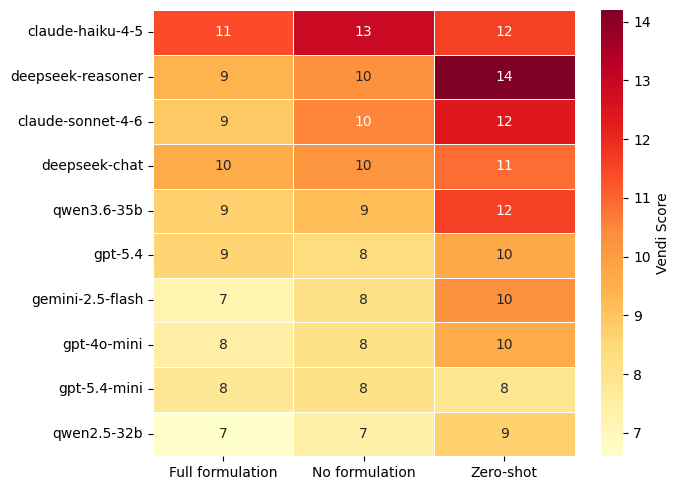

In [95]:
fig, ax = plt.subplots(figsize=(7, 5))
data = pivot_v[[CONDITION_LABELS[c] for c in CONDITION_LABELS]]
sns.heatmap(data, ax=ax, annot=True, fmt=".0f", cmap="YlOrRd",
            linewidths=0.5, cbar_kws={"label": "Vendi Score"})
ax.set_xlabel("")
ax.set_ylabel("")
fig.tight_layout()
FIGURES_DIR = Path("figures")
FIGURES_DIR.mkdir(exist_ok=True)
fig.savefig(FIGURES_DIR / "vendi_heatmap.pdf", bbox_inches="tight", format="pdf")
plt.show()